# Function Approximation

In [40]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import time

# define tile coding
class TileCoder:
    def __init__(self, num_tilings, tiles_per_dim, state_bounds, offset_factor=1.0):
        """
        Args:
            num_tilings (int): Number of overlapping grids.
            tiles_per_dim (list): Number of tiles in [position, velocity].
            state_bounds (list): List of (low, high) tuples for each dimension.
            offset_factor (float): The multiplier for the displacement trick.
        """
        self.num_tilings = num_tilings
        self.tiles_per_dim = np.array(tiles_per_dim)
        self.state_bounds = np.array(state_bounds)
        self.num_dims = len(state_bounds)
        
        # 1. Calculate the width of a single tile in each dimension
        self.tile_widths = (self.state_bounds[:, 1] - self.state_bounds[:, 0]) / self.tiles_per_dim
        
        # 2. Configure asymmetric offsets
        # We pre-allocate a NumPy array instead of a list for efficiency
        self.offsets = np.zeros((num_tilings, self.num_dims))
        
        for i in range(num_tilings):
            for d in range(self.num_dims):
                # Displacement = (i * displacement_vector / num_tilings) * tile_width
                # Standard displacement_vector is usually (2*d + 1)
                self.offsets[i, d] = (i * (offset_factor * (d + 1)) / num_tilings) * self.tile_widths[d]
        
        # 3. Calculate total feature size
        self.features_per_tiling = np.prod(self.tiles_per_dim)
        self.total_features = num_tilings * self.features_per_tiling

    def get_features(self, state):
        feature_vector = np.zeros(self.total_features)
        for i in range(self.num_tilings):
            # Calculate coordinates in the current tiling grid
            # state - low_bound + offset (moves the grid relative to the state)
            coords = (state - self.state_bounds[:, 0] + self.offsets[i]) / self.tile_widths
            tile_indices = np.floor(coords).astype(int)
            tile_indices = np.clip(tile_indices, 0, self.tiles_per_dim - 1)
            
            local_idx = tile_indices[0] + (self.tiles_per_dim[0] * tile_indices[1])
            global_idx = (i * self.features_per_tiling) + local_idx
            feature_vector[int(global_idx)] = 1.0
            
        return feature_vector

# define SARSA agent
class SARSACar:
    def __init__(self, tile_coder, num_actions, alpha=0.1, gamma=1.0, epsilon=0.0):
        self.tc = tile_coder
        # Per lab: alpha should be scaled by num_tilings
        self.alpha = alpha / tile_coder.num_tilings 
        self.gamma = gamma
        self.epsilon = epsilon
        self.num_actions = num_actions
        # Maintain a separate weight vector for each action
        self.weights = np.zeros((num_actions, tile_coder.total_features))

    def get_q(self, state, action):
        """Compute Q(s,a) = w^T x(s) as required by lab."""
        features = self.tc.get_features(state)
        return np.dot(self.weights[action], features)

    def select_action(self, state):
        """Epsilon-greedy action selection."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.num_actions)
        
        # Manual Q-value computation for all actions
        q_values = [self.get_q(state, a) for a in range(self.num_actions)]
        return np.argmax(q_values)

    def update(self, s, a, r, s_next, a_next, done):
        """Semi-gradient SARSA update: w += alpha * (target - Q) * features"""
        features = self.tc.get_features(s)
        current_q = self.get_q(s, a)
        
        if done:
            target = r
        else:
            # Bootstrapping: using Q of next state/action
            target = r + self.gamma * self.get_q(s_next, a_next)
            
        td_error = target - current_q
        
        # Weight update for the action taken
        self.weights[a] += self.alpha * td_error * features

# train model
def train(env, agent, episodes=500):
    stats = []
    for ep in range(episodes):
        state, _ = env.reset()
        action = agent.select_action(state)
        total_steps = 0
        
        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_action = agent.select_action(next_state)
            
            agent.update(state, action, reward, next_state, next_action, done)
            
            state, action = next_state, next_action
            total_steps += 1
            if done: break
            
        stats.append(total_steps)
        if ep % 50 == 0:
            print(f"Episode {ep}, Steps: {total_steps}")
    return stats


# visualization
def visualize_all(agent, env, stats):
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Convergence Curve
    # --- 1. CONVERGENCE CURVES ---
    window_size = 5  # Average over the last 10 episodes
    

    # 1. Plot the raw data (faded in the background)
    line = axs[0, 0].plot(stats, alpha=0.33, color='cornflowerblue')[0]
    
    # 2. Calculate Moving Average
    if len(stats) >= window_size:
        # np.convolve trick for moving average
        means = np.convolve(stats, np.ones(window_size)/window_size, mode='valid')
        
        # 3. Plot the smoothed line (bold, same color as raw)
        x_axis = np.arange(window_size - 1, len(stats))
        axs[0, 0].plot(x_axis, means, color='orange', linewidth=2, alpha=0.67,)

    axs[0, 0].set_title(f"Steps per Episode")
    axs[0, 0].set_xlabel("Episode")
    axs[0, 0].set_ylabel("Steps to Goal")
    
    # Grid for Value/Policy
    pos = np.linspace(-1.2, 0.6, 50)
    vel = np.linspace(-0.07, 0.07, 50)
    P, V = np.meshgrid(pos, vel)
    
    # 2. Value Function Heatmap
    # V(s) = max_a Q(s,a)
    Z_val = np.zeros(P.shape)
    Z_pol = np.zeros(P.shape)
    
    for i in range(len(pos)):
        for j in range(len(vel)):
            s = [pos[i], vel[j]]
            feats = agent.tc.get_features(s)
            q_values = [np.dot(agent.weights[a], feats) for a in range(3)]
            Z_val[j, i] = np.max(q_values)
            Z_pol[j, i] = np.argmax(q_values)
            
    im1 = axs[0, 1].pcolormesh(P, V, Z_val, cmap='viridis', shading='auto')
    plt.colorbar(im1, ax=axs[0, 1], label='Value')
    axs[0, 1].set_title("Learned Value Function")

    # 3. Policy Map
    axs[1, 0].pcolormesh(P, V, Z_pol, cmap='Pastel1', shading='auto')
    axs[1, 0].set_title("Learned Policy")
    
    # 4. Sample Trajectories
    axs[1, 1].pcolormesh(P, V, Z_val, alpha=0.3, cmap='gray')
    for _ in range(3): # Plot 3 random trajectories
        s, _ = env.reset()
        traj = [s]
        for _ in range(200):
            a = agent.select_action(s)
            s, _, term, trunc, _ = env.step(a)
            traj.append(s)
            if term or trunc: break
        traj = np.array(traj)
        axs[1, 1].plot(traj[:,0], traj[:,1], label=f'Start {traj[0,0]:.2f}')
    axs[1, 1].set_title("Sample Trajectories over Value Function")
    plt.legend()

    curr_time = f'{time.time():.2f}'
    plt.tight_layout()
    plt.savefig(f'results_{curr_time}.png')
    plt.show()

## Analysis

8 tiles:
Episode 0, Steps: 200
Episode 50, Steps: 200
Episode 100, Steps: 200
Episode 150, Steps: 200
Episode 200, Steps: 200
Episode 250, Steps: 176
Run time: 13.89


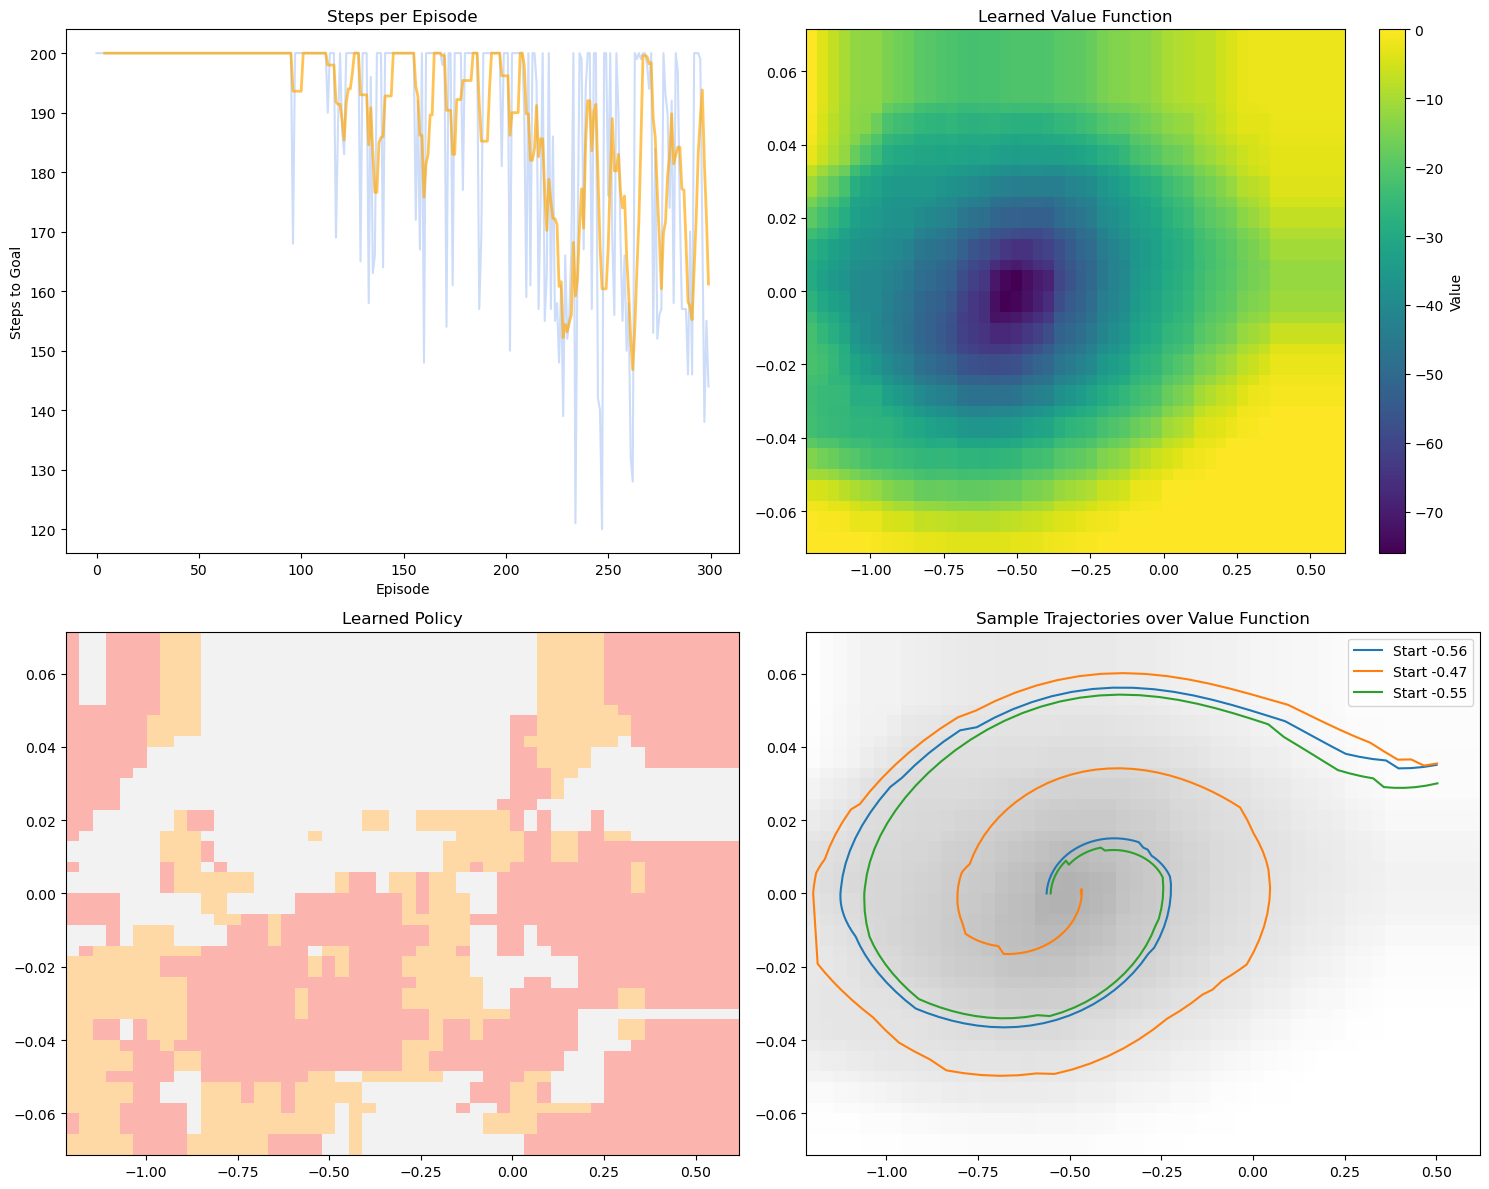

24 tiles:
Episode 0, Steps: 200
Episode 50, Steps: 200
Episode 100, Steps: 200
Episode 150, Steps: 128
Episode 200, Steps: 200
Episode 250, Steps: 129
Run time: 38.62


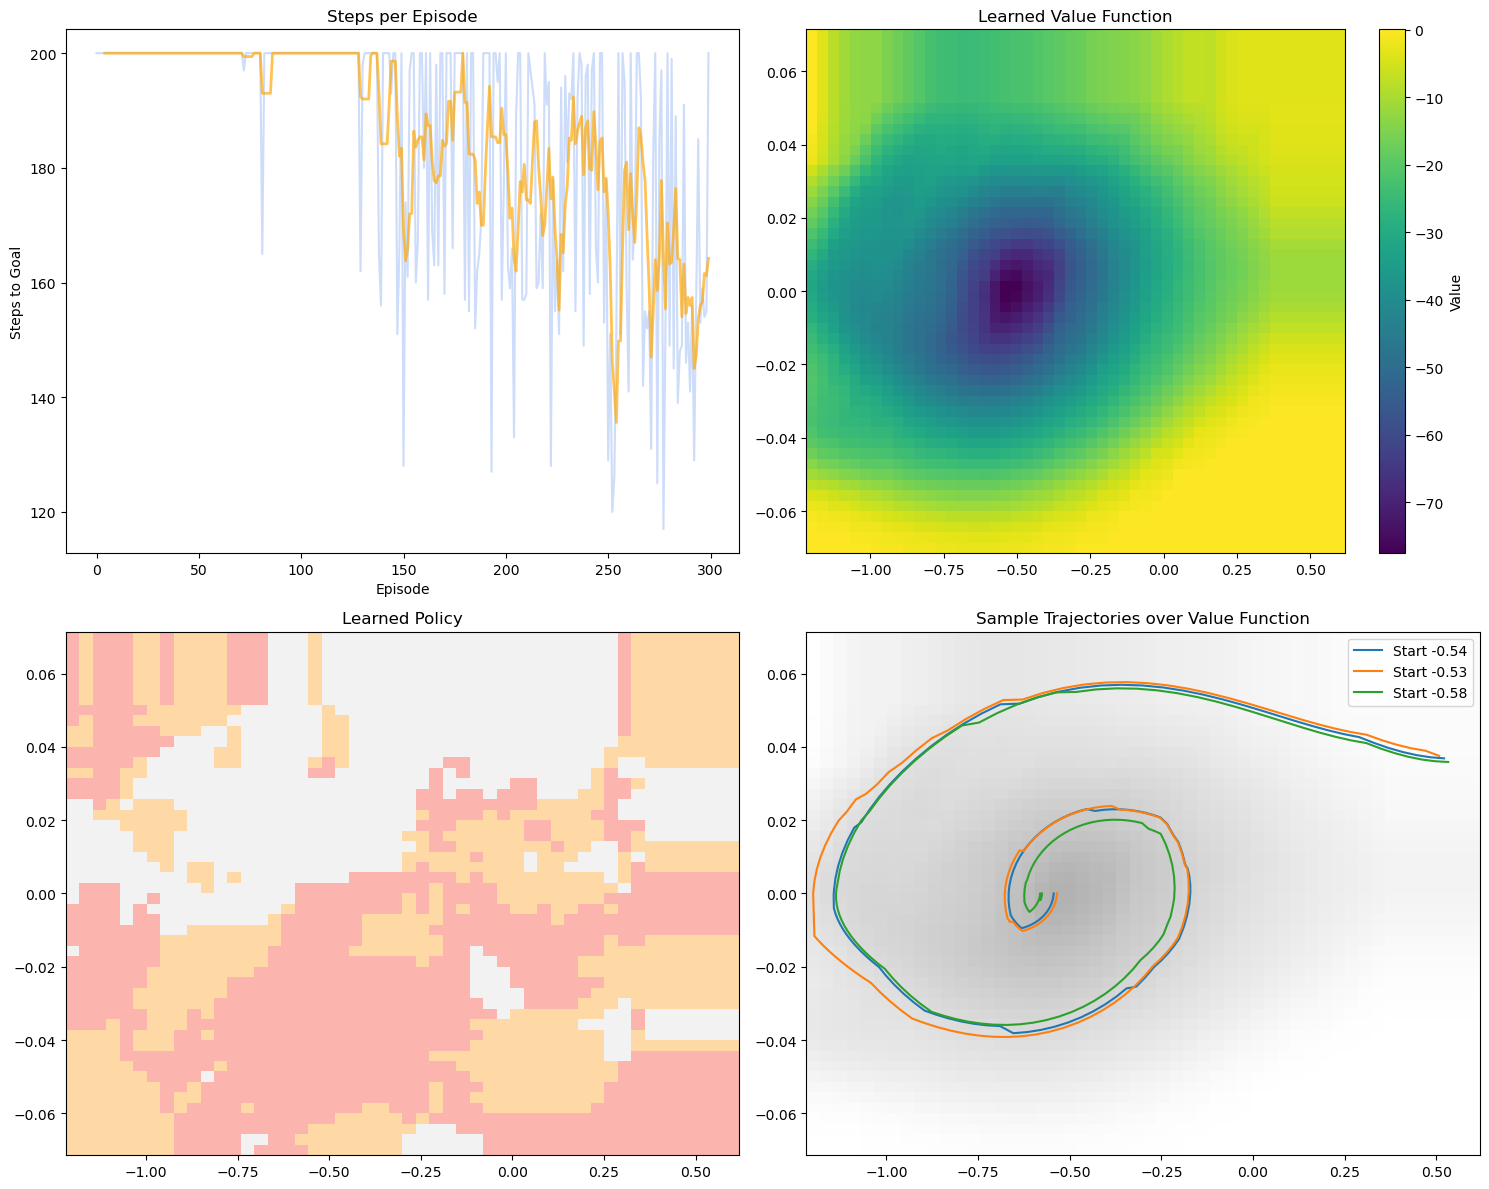

24 tiles:
Episode 0, Steps: 200
Episode 50, Steps: 200
Episode 100, Steps: 200
Episode 150, Steps: 200
Episode 200, Steps: 200
Episode 250, Steps: 200
Run time: 94.89


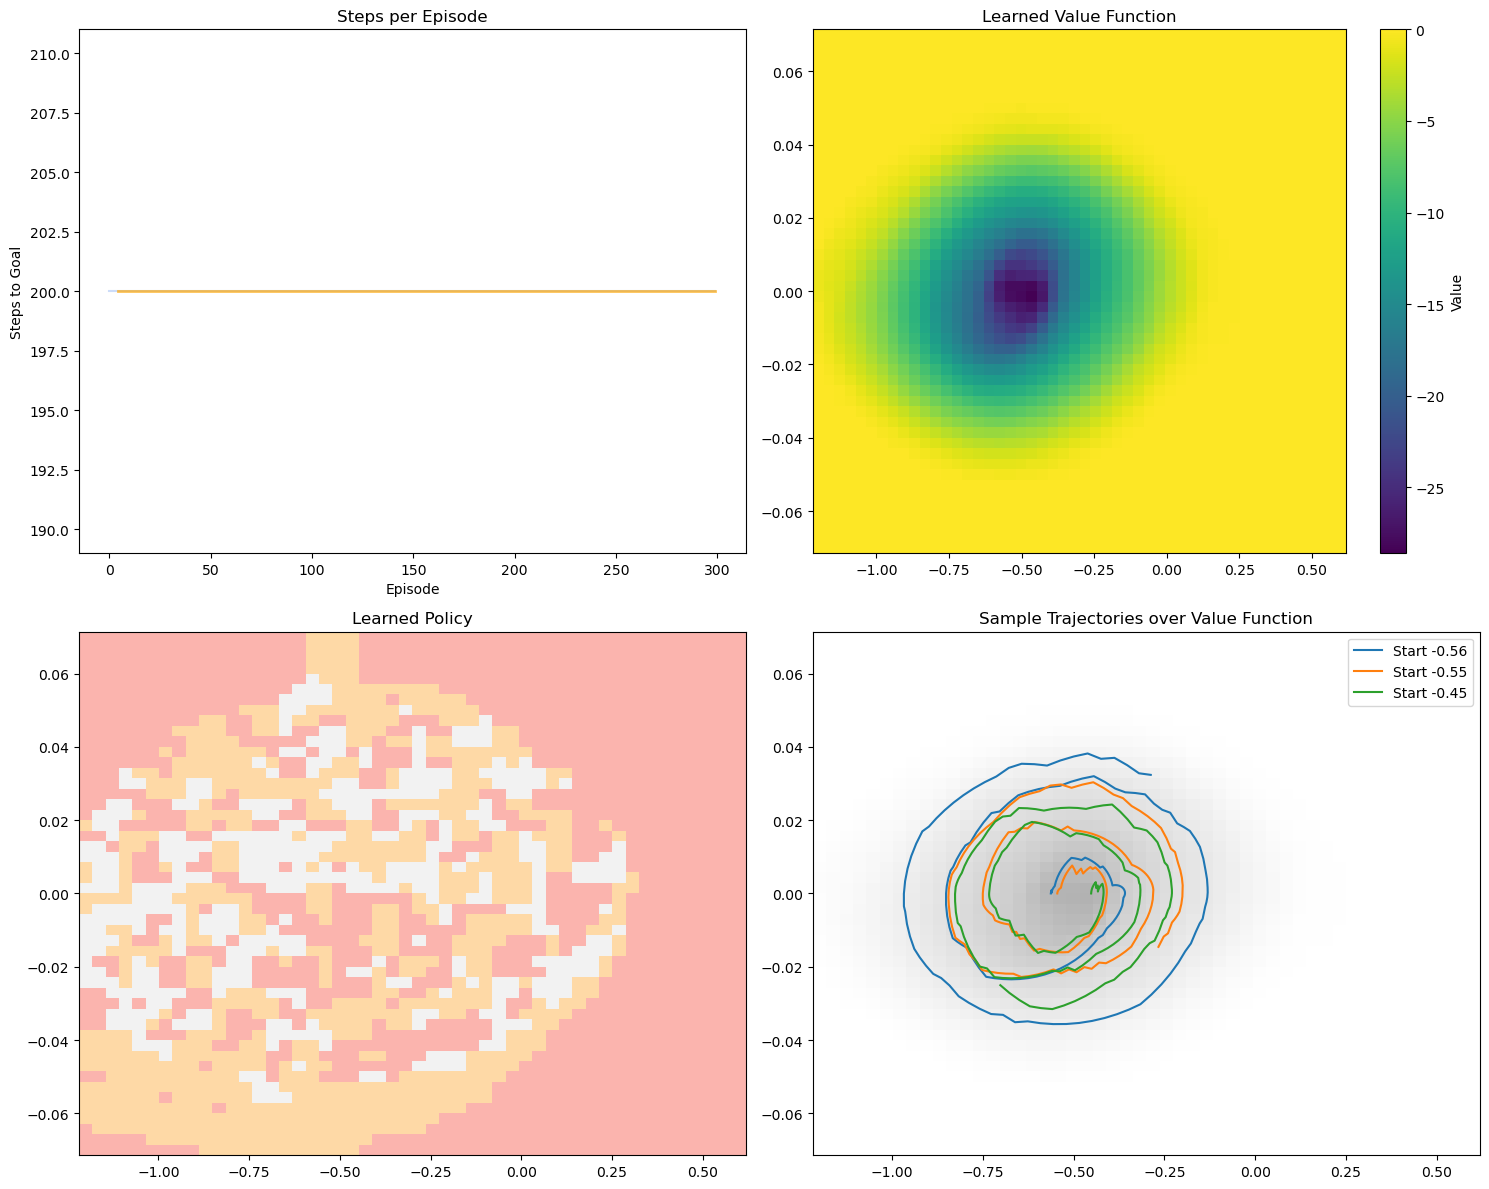

In [42]:
### train models
n_episodes = 300 # for consistency across functions

# low tile count
print('8 tiles:')
start_time = time.time()
env = gym.make('MountainCar-v0')
tc = TileCoder(num_tilings=8, tiles_per_dim=[8, 8], state_bounds=[(-1.2, 0.6), (-0.07, 0.07)])
agent = SARSACar(tc, num_actions=3, alpha=0.1, epsilon=0.07) # looping through epsilons showed 0.07 as best for convergence
stats = train(env, agent, episodes=n_episodes)
end_time = time.time()
print(f'Run time: {(end_time - start_time):.2f}')
visualize_all(agent, env, stats)

# 3x increased tile count, same tile size
print('24 tiles:')
start_time = time.time()
env = gym.make('MountainCar-v0')
tc = TileCoder(num_tilings=24, tiles_per_dim=[8, 8], state_bounds=[(-1.2, 0.6), (-0.07, 0.07)])
agent = SARSACar(tc, num_actions=3, alpha=0.1, epsilon=0.07) # looping through epsilons showed 0.07 as best for convergence
stats = train(env, agent, episodes=n_episodes)
end_time = time.time()
print(f'Run time: {(end_time - start_time):.2f}')
visualize_all(agent, env, stats)

# 3x increased tile count, 3x increased tile size
print('24 tiles:')
start_time = time.time()
env = gym.make('MountainCar-v0')
tc = TileCoder(num_tilings=24, tiles_per_dim=[24, 24], state_bounds=[(-1.2, 0.6), (-0.07, 0.07)])
agent = SARSACar(tc, num_actions=3, alpha=0.1, epsilon=0.07) # looping through epsilons showed 0.07 as best for convergence
stats = train(env, agent, episodes=n_episodes)
end_time = time.time()
print(f'Run time: {(end_time - start_time):.2f}')
visualize_all(agent, env, stats)

## Design Choice

#### Sensitivity Analysis
- n_samples = 4, n_episodes = 150 can be reduced for computational speed

Generating Sobol samples (N=4, D=3).
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps: 200
Episode 0, Steps:

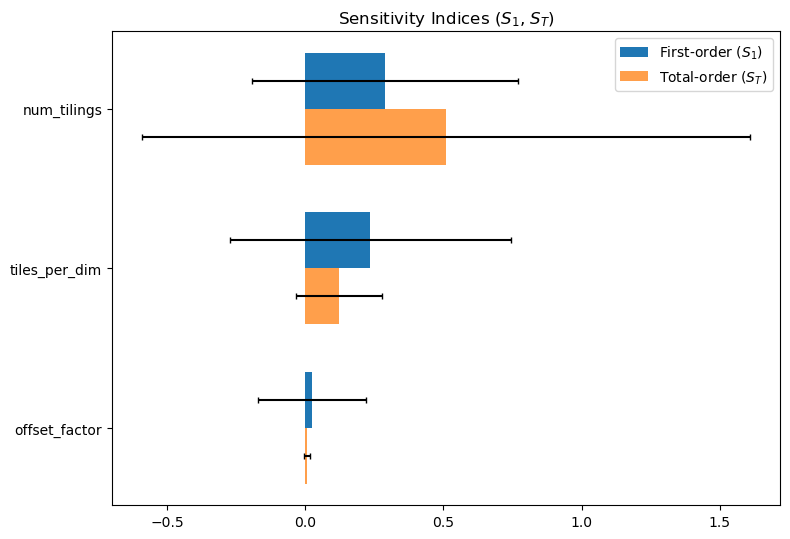

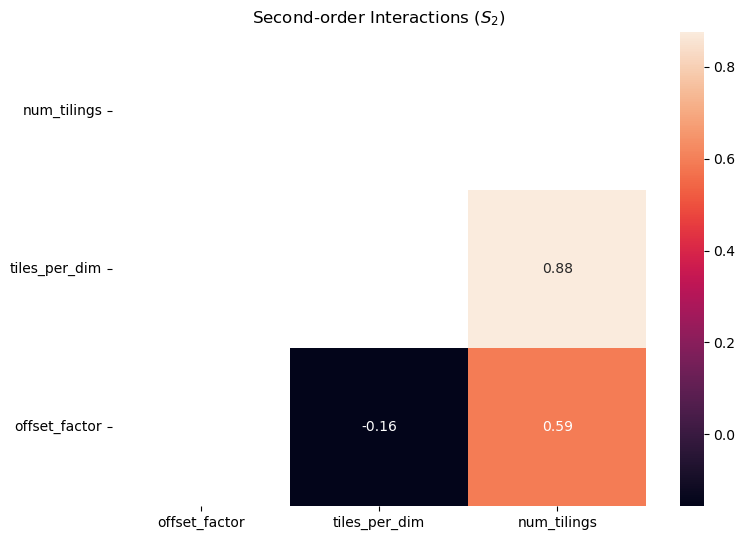

In [17]:
### train model
import hdim_opt
import time
import pandas as pd
import seaborn as sns

def evaluate_config(params):
    '''Evaluates the input configuration samples (n_tilings, t_per_dim, offset_factor).'''
    n_tilings = int(params[0])
    t_per_dim = int(params[1])
    off_fact = params[2]
    
    env = gym.make('MountainCar-v0')
    
    # Updated TileCoder to accept the offset_factor
    tc = TileCoder(
        num_tilings=n_tilings, 
        tiles_per_dim=[t_per_dim, t_per_dim], 
        state_bounds=[(-1.2, 0.6), (-0.07, 0.07)],
        offset_factor=off_fact
    )
    
    agent = SARSACar(tc, num_actions=3, alpha=0.1, epsilon=0.07)
    
    start_time = time.time()
    stats = train(env, agent, episodes=n_episodes)
    comp_time = time.time() - start_time
    final_performance = np.mean(stats[-15:])
    best_performance = np.min(stats)
    
    return final_performance, best_performance, comp_time

def sensitivity_objective(params_matrix):
    '''Objective function for the sensitivity analysis (calls evaluate_config).'''
    if params_matrix.ndim == 1: # handle shape conflicts
        params_matrix = params_matrix.reshape(1, -1)
    
    batch_results = []
    for row in params_matrix:
        # evaluate configuration
        final_performance, best_performance, comp_time = evaluate_config(row)
        
        # store data for dataframe
        all_trials.append({
            'num_tilings': int(row[0]),
            'tiles_per_dim': int(row[1]),
            'offset_factor': row[2],
            'final_performance': final_performance,
            'best_performance': best_performance,
            'cost': comp_time
        })
        
        batch_results.append(comp_time)
    
    return np.array(comp_time)

### hyperparameter bounds for sensitivity analysis
n_episodes = 50 # smaller number for runtime
hyperparameter_bounds = [
    (2.0, 64.0),    # num_tilings
    (2.0, 64.0),   # tiles_per_dim
    (0.0, 10.0),     # offset_factor
]

### sobol sensitivity analysis      (FOR FASTER RUN TIME, lower the n_episodes or n_samples)
all_trials = []
sens = hdim_opt.sensitivity(sensitivity_objective, hyperparameter_bounds, n_samples=4, 
                            param_names=['num_tilings', 'tiles_per_dim', 'offset_factor'])

### analyze results
df = pd.DataFrame(all_trials)

#### Visualizations


Results:


,num_tilings,tiles_per_dim,offset_factor,final_performance,best_performance,cost
0,31,14,5.504792,200.000000,200,9.134812
1,37,14,5.504792,199.066667,186,10.555022
2,31,22,5.504792,200.000000,200,18.388326
3,31,14,1.494484,200.000000,200,9.313145
4,31,22,1.494484,200.000000,200,19.797577


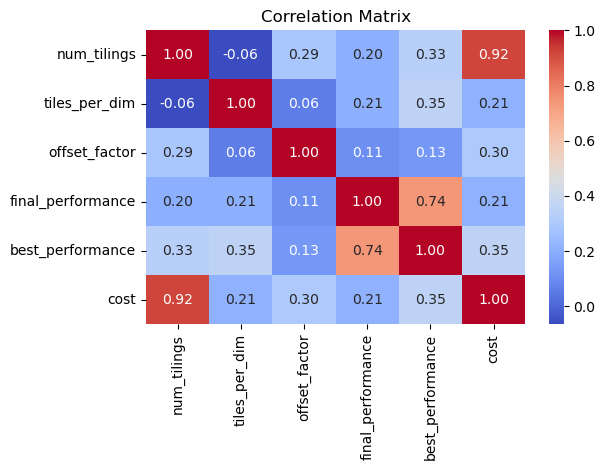

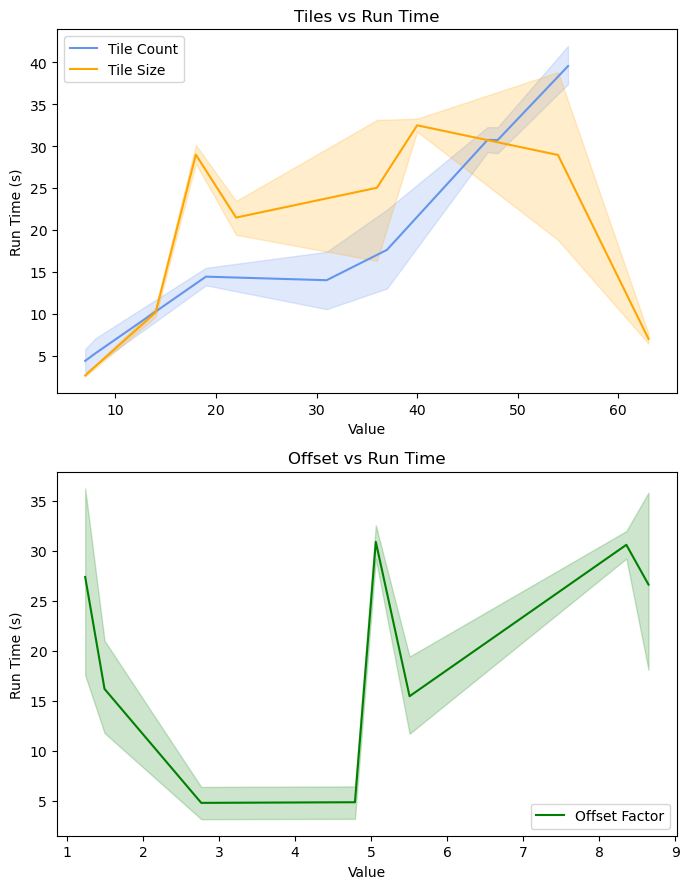

In [39]:
# param 1 vs runtime & best_performance
# param 2 vs runtime & best_performance
# param 3 vs runtime & best_performance

print('\nResults:')
display(df.head())

# correlation matrix
sns.heatmap(df.corr(), annot=True, fmt= '.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('corr.png')
plt.show()

# tile comparison
fig, axs = plt.subplots(2,1,figsize=(7,9))
sns.lineplot(data=df,x='num_tilings',y='cost',color='cornflowerblue',label='Tile Count', ax=axs[0])
sns.lineplot(data=df,x='tiles_per_dim',y='cost',color='orange',label='Tile Size', ax=axs[0])
axs[0].set_title('Tiles vs Run Time')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Run Time (s)')

# offset
sns.lineplot(data=df,x='offset_factor',y='cost',color='green',label='Offset Factor', ax=axs[1])
axs[1].set_title('Offset vs Run Time')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Run Time (s)')

plt.tight_layout()
plt.savefig('runtimes.png')
plt.show()